# Car Crash Accident Prediction for Insurance Company

In [0]:
%pip install -q datasets==2.20.0 transformers==4.49.0 tf-keras==2.17.0 accelerate==1.4.0 mlflow==2.20.2 torchvision==0.20.1 deepspeed==0.14.4
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


# Import Library

In [0]:
import io
import os
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import mlflow
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient

import torch
import torchvision
import datasets
from datasets import Dataset, load_dataset

from transformers.utils import logging as hf_logging
from transformers import AutoFeatureExtractor, AutoImageProcessor, AutoModelForImageClassification, TrainingArguments, Trainer, pipeline, DefaultDataCollator, EarlyStoppingCallback


from PIL import Image
from pyspark.sql.functions import pandas_udf, col

# Data Ingestion

In [0]:
# LOAD TRAIN IMAGES DATA
train_img = spark.read.table(tableName = "claim_insurance.2_silver.training_images")
display(train_img.limit(1))

path,modificationTime,length,content,label
dbfs:/Volumes/claim_insurance/object_storage/training_images/14-ok (3).png,2026-05-05T20:02:47.000Z,1319008,...,ok


# Preprocessing Image

In [0]:
# PREPROCESSING IMAGE

# PATH CONFIGURATION
source_catalog = "claim_insurance"
source_schema = "object_storage"
base_path = f"/Volumes/{source_catalog}/{source_schema}"
metadata_path = f"{base_path}/metadata"

# IMAGE RESIZE
IMAGE_RESIZE = 224

# RESIZE IMAGE AND SERIALIZE BACK INTO JPEG
@pandas_udf("binary")
def resize_image_udf(content_series):
  def resize_image(content):

    # LOAD IMAGE
    image = Image.open(io.BytesIO(content))
    width, height = image.size   # Get dimensions
    new_size = min(width, height)

    # CROP THE CENTER OF IMAGE & RESIZE IT TO THE NEW RESOLUTION
    image = image.crop(((width - new_size)/2, (height - new_size)/2, (width + new_size)/2, (height + new_size)/2))
    image = image.resize((IMAGE_RESIZE, IMAGE_RESIZE), Image.NEAREST)

    # SAVE BACK AS JPEG
    output = io.BytesIO()
    image.save(output, format='JPEG')

    return output.getvalue()
  return content_series.apply(resize_image)

# METADATA TO ENABLE IMAGE PREVIEW
image_meta = {"spark.contentAnnotation" : '{"mimeType": "image/jpeg"}'}

# APPLY RESIZE IMAGE
train_img = train_img.withColumn(colName = "content", col = resize_image_udf(col("content")).alias("content", metadata = image_meta))

# SAVE PREPROCESSED IMAGE ON SILVER FOLDER
train_img.write.mode(saveMode = "overwrite").saveAsTable(name = "claim_insurance.2_silver.training_images_processed")

display(train_img.limit(1))

path modificationTime length content label dbfs:/Volumes/claim_insurance/object_storage/training_images/14-ok (3).png 2026-05-05T20:02:47.000Z 1319008 /9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjL/wAARCADgAOADASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVWV1hZWmNkZWZnaGlqc3R1dnd4eXqDhIWGh4iJipKTlJWWl5iZmqKjpKWmp6ipqrKztLW2t7i5usLDxMXGx8jJytLT1NXW19jZ2uHi4+Tl5ufo6erx8vP09fb3+Pn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3+Pn6/9oADAMBAAIRAxEAPwDwGkpaKACiiigBKKWigAopKKAFopKWgDq/DD5uHjP8Sbvyx/jU+pRGKZh61T8LtjU0Xu0ZA/Q/0rb1+AhGcdvmFIl7na/B/wATPpXiCOwmkAsNU/djJ4ScZ2/QtyMd8j0r6Fr4z0udjHPEJSjDE0Tc/KwOeP0/DNfVPgbxGvijwlZ6gW/0kL5V0v8AdmXhh/X6EUwXY6OjNfPFx4x8ReKNWnU35t0tgBttmZBnLY/i64H8qS4+J3izwpaq5uIb+33bcXSlj/30CDTsL2i5uU+iaK8x+H/xj0zxldDTrq2On6kRlEL7kl6fdPBz7Y/E16aDkZpFJ3FooooGFFFJQAtFFFACUtJRQAUUtFAHwFS1058LwZ4uJMe4FH/CLw/8/En5ClcVzl6Wun/4ReAf8vEn5Cl/4ReD/n4k/IUXC6OXpK6seF7fvPJ+Qpw8MWueZpf0/wAKLhdHJUV2A8L2XeSb8x/hTv8AhGLHP35/++h/hRcLnHUqgswA712sfhnTlOWErD3b/Cr1tpen2rbobWMNngsNxH0zRcLmfoOnNaeXfTKRllWNe/zHbk/nXQavEHthVe8n8uzmkHJRCw+oGavXbJNDgEHtSRLetzhLWb7LeIzdEYqwPdTW9pHjvXvB5ubbSrl4bKaX96qorZYDbuG4HBIweMdqwdRgMV4/GA1bOkwx6lbJuijZbdlN0hOGePIBYADJIBPrxnimhvuM8E63DbveW87lZrkgh26HAPf15NW/GeoQz6WkEbK7FwflOa9103wH4TFuslpoWmyRv8wZoFkz+LZrfsvDthYrttLC2t164ihVR+gqr6WJ9mubmufPHwt8J32q+JtK1C3spoLWzkEs91ICEcq2dqnuegxX1VCcoKpQWhU9Kvou0YpGg+iiigAooooAKKKKACiiigAoopKAPkrFLiqDahIp/wBQp+kn/wBam/2nL/z7r+Mh/wDiax9rDudX9n4n+X8V/maOKUVnrqbfxQLj2c//ABNSjVYf4o2H05p+1h3E8vxK+x+RcApapjVbX+5L+Q/xpf7Vtv7k/wCS/wCNHtIdxfUcT/Iy4OlLWf8A2tDniGfH/Af/AIqnrqlueqyL9Uz/ACp88e5Dwldbwf3Mu8UZx3qsb6EAE7wPUqRT0uIZh+7kU+2aaaexlKnOHxJr1I9QcjT7nB6xNn8qguJHAyGIqTUARYXH/XNv5GorgcE4pkox7uR5CQxz9adpl/Jp19HcxNjHB9weoqK6PJqqjZJX1oKPY/AHiyWy8Q6da+dIba4lEE0ZPy5bgNj64OfSvoIIo7V8X6ZdYkjOcEEKf6V9b+EdVl1rwrp9/PzNJGVduPmZSVLcepXP41RMdNDaApaSloKCiiigAooooAKKKKACiiigBKWiigD4l8xc9j+FAdP7q/lUItbg/wAJp62Vwf4TUam1kPJjPVFP4U0+WP4F/IVIum3Dfw5qZdFuXx8lLUd4oosY8fdWoywHRRW1H4bu3/hP5GrcfhC6bqp/KizFzxXU5csT/wDrqMiTs7D8a7ePwVMfvZFWk8EoBl3wPc0+Vi9ul1PO/wDSV+7K350F7zIJLNjpz0r09PBtmg3OeO5zVmLQdFj5DxPg4+Vt3P4U+TyF9aeykzzOLWbtYXt5VaRXUr83JGRjg119zbBrdZACNy7hkYrUurfT31KwgtLZy0UguZWEe3aq525z6tj8jS6ze2otg8s0UZbgK0q5+uM5ppWMZzUnexwN6u1jWaWYZAYgE5I7Vr3iSTszRRMY+u8qQP1AqgLT5vnbPstQ6kV1Oung687PlaXnoS6cxM4P8JIzzjmvqH4Qarb3/gpLaN8zWkjJIuemTkH2/wAQa+Yks3RTIQVjA/hGSPr7dK7r4Z+LT4b8ZW7zystnenyLoE5APZzk9mwc+hNKFRSdkPE4SVBJyPqKloorU5QooooAKKKKACiiigAooooAKSlooA+bV0G2/wCeX61OmiWyYzCPxriB4sAP+uuvyH+NP/4S8bSxnvAB1xj/ABqroy5ZHex6RbKOIFqylpAg4jQY9q4iy8SyugYLqLq3IIRiCPr0qa41mR3bZA4cDrcTqn04XcTUOtBaNnRDA4mavGDt36ffsdmZbeJtuVJ9FGf5Upuohu2gEqM57VwD6pqc20m5jjB6/Z4dx/N84/KoUtp7iQiSW7nB4/fXBxj6LgVjLFQjv/X32OyjkmJq7W/P/wBJTOovtctjdPnW4LKCMDiNVd3PfkggY9MVntrtjNsaJtU1BhyGLNEv1wAqmqttpLQkmOKCEEY+ROT+NWBp0CHdNcfMOhLc/rXNLMI9P1f+X5nrUeGXvNv8F+PvP8Bj6zdyTiSOwhUDgPIVyPwUMf8Ax4VSvtX1KOKYvebERcqYIwnPpliT+VaYXTYWySZG9z1rH1rULYXNtbxwBVVxI2ABn0HH5/lWdPFzqTUV/l/wTpr5PhsNQlUkk2trtvV/cvwK9jpl1dQPLMtxPNMR5jeYwHsOCOn41s2ugeQ+5Y4IePvBAT+fWg61DDGgIDEqOBVu21SOdfkRfpiuadarUb00/ruetRwWGw6SurrtZfikm/vKl1pkSx5nnaXGcViTQiKTCQ4A6V0V/qRWAhFjBA71xt7fXEzkFjyf4adKE29dh4ivh4QvbX+urH3V2qIyHnPG0DAqiJHKs+OVw2fbGP8AD8qUQFh5kgO0HOD1b2qqZctIc/e49q9ChFJ2R8zm05zp801bsvI+tPhb4lbxP4HtZ55WkvLYm3uGbqSvQ++VK8+ua7Svm34C64bHxfNpckrCK/gYIgPBkX5gT/wEOPxr6SrsPn0FFFFAwooooAKKKKAEopaKACiiigD5HOgWv9z9BUT6JBiWEINrxt+eMj+VdH5YqMRg3kfH8LZ+mKdkZqTOW0u6XyFhnaR3jwhRmwoHY8DP+TWuIYsAxiMEdPlyfzNYgtTMN6YEqkjPr7Gpop5IH8qVWRgB8rDHbP8AI5ry8Vh5Rd4vQ+2ybMqVaKhVSc0t+rXe+5bnmmUlF

# Set MLFlow

In [0]:
# CONFIGURE MLFLOW
mlflow.set_experiment(experiment_name = "/Users/aliipa16@gmail.com/car_crash_pytorch")


<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/2730824160813174', creation_time=1778083291088, experiment_id='2730824160813174', last_update_time=1778233464090, lifecycle_stage='active', name='/Users/aliipa16@gmail.com/car_crash_pytorch', tags={'mlflow.experiment.sourceName': '/Users/aliipa16@gmail.com/car_crash_pytorch',
 'mlflow.experimentKind': 'custom_model_development',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'aliipa16@gmail.com',
 'mlflow.ownerId': '73170364539131'}>

# Split Dataset Train & Test

In [0]:
# SPLIT DATASET

# 1. TEMP PATH FOR IMAGES
temp_path = "/Volumes/claim_insurance/object_storage/temp_images"
spark.table("claim_insurance.2_silver.training_images_processed").write.mode("overwrite").parquet(temp_path)

# LOAD WITH HF DATASET
dataset = load_dataset("parquet", data_files=f"{temp_path}/*.parquet", split="train")

# SPLIT DATA INTO TRAIN AND TEST
splits_ratio = dataset.train_test_split(test_size = 0.2, seed = 2026)
train_dataset = splits_ratio["train"]
val_dataset = splits_ratio["test"]

train_dataset

/databricks/python_shell/lib/dbruntime/huggingface_patches/datasets.py:56: UserWarning: The cache_dir for this dataset is /tmp/.hf.data.cache, which is not a persistent path.Therefore, if/when the cluster restarts, the downloaded dataset will be lost.The persistent storage options for this workspace/cluster config are: [UC Volumes].Please update either `cache_dir` or the environment variable `HF_DATASETS_CACHE`to be under one of the following root directories: ['/Volumes/']
  warnings.warn(warning_message)
/databricks/python_shell/lib/dbruntime/huggingface_patches/datasets.py:24: UserWarning: During large dataset downloads, there could be multiple progress bar widgets that can cause performance issues for your notebook or browser. To avoid these issues, use `datasets.utils.logging.disable_progress_bar()` to turn off the progress bars.
  warnings.warn(


Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['path', 'modificationTime', 'length', 'content', 'label'],
    num_rows: 44
})

# Transform Images

In [0]:
# FEATURE EXTRACTOR & TRANSFORM IMAGE

model_name = "microsoft/resnet-50"

# DEFINE FEATURE EXTRACTOR
model_extract = AutoFeatureExtractor.from_pretrained(model_name)

# TRANSFORM IMAGE
transforms = torchvision.transforms.Compose([torchvision.transforms.Lambda(lambda b: Image.open(io.BytesIO(b)).convert("RGB")), # CONVERT BYTES IMG TO RGB
                                             torchvision.transforms.ToTensor(), # CONVERT RGB TO TENSOR
                                             torchvision.transforms.Normalize(mean = model_extract.image_mean, # NORM
                                                                              std = model_extract.image_std)])

# TRANSFORM IMAGE PER BATCH
def preprocess(batch):
    batch["image"] = [transforms(image) for image in batch["content"]]
    return batch

# APPLY TRANSFORMATION
train_dataset.set_transform(preprocess)
val_dataset.set_transform(preprocess)


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

/local_disk0/.ephemeral_nfs/envs/pythonEnv-165ef1f9-7f1f-4975-8941-4c102247b2b1/lib/python3.12/site-packages/transformers/models/convnext/feature_extraction_convnext.py:28: FutureWarning: The class ConvNextFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ConvNextImageProcessor instead.
  warnings.warn(


# Define Model

In [0]:
# LABEL MAPPING (TRANSFORM STRING LABEL TO INT)
label2id, id2label = dict(), dict()
for i, label in enumerate(set(dataset['label'])):
    label2id[label] = i   # STRING LABEL TO INT
    id2label[i] = label   # INT TO STRING LABEL

# LOAD RESNET MODEL
model = AutoModelForImageClassification.from_pretrained(model_name, 
                                                        num_labels = len(label2id), 
                                                        label2id = label2id, 
                                                        id2label = id2label,
                                                        ignore_mismatched_sizes = True # ABAIKAN LABEL YG TIDAK ADA
                                                        )

model

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Some weights of ResNetForImageClassification were not initialized from the model checkpoint at microsoft/resnet-50 and are newly initialized because the shapes did not match:
- classifier.1.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.1.weight: found shape torch.Size([1000, 2048]) in the checkpoint and torch.Size([3, 2048]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ResNetForImageClassification(
  (resnet): ResNetModel(
    (embedder): ResNetEmbeddings(
      (embedder): ResNetConvLayer(
        (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activation): ReLU()
      )
      (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (encoder): ResNetEncoder(
      (stages): ModuleList(
        (0): ResNetStage(
          (layers): Sequential(
            (0): ResNetBottleNeckLayer(
              (shortcut): ResNetShortCut(
                (convolution): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
                (normalization): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              )
              (layer): Sequential(
                (0): ResNetConvLayer(
                  (convolution): Conv2d(64

In [0]:
aa

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-6472638225673980>, line 1
----> 1 aa

NameError: name 'aa' is not defined

In [0]:
import os
import mlflow
import datasets
from transformers.utils import logging as hf_logging



# ==========================================
# 2. NUKE DATABRICKS AUTOLOGGING & TELEMETRY
# ==========================================
mlflow.autolog(disable=True)
os.environ["WANDB_DISABLED"] = "true"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1" 

# ==========================================
# 3. MATIKAN PROGRESS BAR (Mencegah Hang UI)
# ==========================================
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
datasets.utils.logging.disable_progress_bar()
hf_logging.disable_progress_bar()


# ==========================================
# 4. KODEMU (SETTING TRAINING ARGUMENTS)
# ==========================================
model_name = model_name.split("/")[-1]

args = TrainingArguments(
    output_dir=f"/tmp/huggingface/pcb/{model_name}-finetuned",
    use_cpu=True, 
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=5,
    load_best_model_at_end=True,
    report_to="none" 
)
args

In [0]:
# SETTING TRAINING ARGUMENTS

# ==========================================
# 1. MATIKAN PYTORCH DISTRIBUTED (FIX TCPStore Error!)
# ==========================================
# Hapus jebakan Databricks yang bikin HF ngira ini mesin Distributed
for env_var in ['WORLD_SIZE', 'RANK', 'LOCAL_RANK', 'MASTER_ADDR', 'MASTER_PORT']:
    os.environ.pop(env_var, None)

model_name = model_name.split("/")[-1]

# DEFINE TRAINING PARAMETER
args = TrainingArguments(f"/tmp/huggingface/pcb/{model_name}-finetuned",
                         use_cpu=True,
                         remove_unused_columns=False,
                         eval_strategy = "epoch",
                         save_strategy = "epoch",
                         num_train_epochs = 5,
                         load_best_model_at_end=True,
                         report_to = "none")
args

TrainingArguments(
_n_gpu=0,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=False,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
dispatch_batches=None,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval

In [0]:
# FUNCTION TO INFERENCE MODEL WRAPPER

# This wrapper adds steps before and after the inference to simplify the model usage
class ModelWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, pipeline):
        self.pipeline = pipeline
        # instantiate model in evaluation mode
        self.pipeline.model.eval()

    def predict(self, context, images):

        with torch.set_grad_enabled(False):
            # CONVERT BYTE IMG INTO RGB
            images = images['content'].apply(lambda b: Image.open(io.BytesIO(b))).to_list()

            # RETURN THE PROBABILITY FOR ALL THE CLASSES
            predictions = self.pipeline.predict(images)

            # RETURN ONLY CLASS WITH THE HIGHEST SCORE
            return pd.DataFrame([max(r, key=lambda x: x['score']) for r in predictions])

/local_disk0/.ephemeral_nfs/envs/pythonEnv-165ef1f9-7f1f-4975-8941-4c102247b2b1/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:135: FutureWarning: Model's `predict` method contains invalid parameters: {'images'}. Only the following parameter names are allowed: context, model_input, and params. Note that invalid parameters will no longer be permitted in future versions.
  param_names = _check_func_signature(func, "predict")
/local_disk0/.ephemeral_nfs/envs/pythonEnv-165ef1f9-7f1f-4975-8941-4c102247b2b1/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:166: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


# Train Model & Config Model Pipeline

In [0]:
# MLFLOW EXPERIMENT TRACKING

# START MLFLOW RUN
with mlflow.start_run(run_name = "hugging_face_new") as run:

    # CATAT DATASET KE DALAM MLFLOW
    mlflow.log_input(mlflow.data.from_huggingface(train_dataset, "training"))

    # PREPROCESSING BATCH DATA AND RETURN EXTRACTED IMAGE & LABELS
    def collate_fn(examples):

        # TUMPUK GAMBAR JADI 1
        pixel_values = torch.stack([e["image"] for e in examples])

        # CONVERT LABELS TO ONE-HOT ENCODED VECTOR
        labels = torch.tensor([label2id[e["label"]] for e in examples], dtype=torch.long)
        labels = torch.nn.functional.one_hot(labels, num_classes=len(label2id)).float()
        return {"pixel_values": pixel_values, "labels": labels}
    
    # TRAIN MODEL
    trainer = Trainer(model, args, 
                      train_dataset = train_dataset, 
                      eval_dataset = val_dataset,
                      processing_class = model_extract, 
                      data_collator = collate_fn)
    train_results = trainer.train()

    # BUILD HUGGING FACE PIPELINE
    classifier = pipeline("image-classification", 
                          model = trainer.state.best_model_checkpoint, 
                          image_processor = model_extract)

    # WRAP MODEL SUPAYA BISA DI LOG KE MLFLOW
    wrapped_model = ModelWrapper(classifier)

    # PREDICT MODEL 
    test_df = spark.table("claim_insurance.2_silver.training_images_processed").select('content').toPandas()
    predictions = wrapped_model.predict(None, test_df)

    # AUTO DETECT SCHEMA
    signature = infer_signature(test_df, predictions)

    # AUTO DETECT LIBRARY YG DIGUNAKAN 
    reqs = mlflow.transformers.get_default_pip_requirements(model)

    # SAVE MODEL TO MLFLOW AS ARTIFACT
    logged = mlflow.pyfunc.log_model(artifact_path = "model", 
                                     python_model = wrapped_model,
                                     pip_requirements = reqs,
                                     signature = signature)

# DEBUGGING
print("logged.model_uri:", logged.model_uri)   # e.g., runs://model
print("logged.run_id  :", logged.run_id)
print("model files    :", mlflow.artifacts.list_artifacts(logged.model_uri))


[2026-05-08 09:57:58,428] [WARNING] [real_accelerator.py:162:get_accelerator] Setting accelerator to CPU. If you have GPU or other accelerator, we were unable to detect it.
[2026-05-08 09:57:58,429] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cpu (auto detect)


/local_disk0/.ephemeral_nfs/envs/pythonEnv-165ef1f9-7f1f-4975-8941-4c102247b2b1/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,No log,0.684194
2,No log,0.687686
3,No log,0.688871
4,No log,0.689811
5,No log,0.689009


Device set to use cpu
/local_disk0/.ephemeral_nfs/envs/pythonEnv-165ef1f9-7f1f-4975-8941-4c102247b2b1/lib/python3.12/site-packages/mlflow/pyfunc/__init__.py:3210: UserWarning: An input example was not provided when logging the model. To ensure the model signature functions correctly, specify the `input_example` parameter. See https://mlflow.org/docs/latest/model/signatures.html#model-input-example for more details about the benefits of using input_example.
  color_warning(


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

logged.model_uri: runs:/3a3abf589b874e688486c95b0e723744/model
logged.run_id  : 3a3abf589b874e688486c95b0e723744
model files    : [<FileInfo: file_size=788, is_dir=False, path='model/MLmodel'>, <FileInfo: file_size=199, is_dir=False, path='model/conda.yaml'>, <FileInfo: file_size=122, is_dir=False, path='model/python_env.yaml'>, <FileInfo: file_size=94416989, is_dir=False, path='model/python_model.pkl'>, <FileInfo: file_size=86, is_dir=False, path='model/requirements.txt'>, <FileInfo: file_size=None, is_dir=True, path='model/metadata'>]


# Register Model to MLFLOW

In [0]:
# REGISTER MODEL MLFLOW

# SET DATABRICKS (on DATABRICKS)
mlflow.set_registry_uri("databricks-uc")

# REGISTER MODEL TO MLFLOW (MEMASUKKAN MODEL HASIL TRAINING KE DALAM VERSIONING MODEL RESMI)
model_name = "claim_insurance.3_gold.car_damage_level"
registered = mlflow.register_model(model_uri = logged.model_uri, name = model_name)

# KASIH NAMA ALIAS
MlflowClient().set_registered_model_alias(name = model_name, 
                                          alias = "prod", 
                                          version = registered.version)
print(f"Registered {model_name} v{registered.version} and set alias 'prod'.")

Successfully registered model 'claim_insurance.3_gold.car_damage_level'.


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Created version '1' of model 'claim_insurance.3_gold.car_damage_level'.


Registered claim_insurance.3_gold.car_damage_level v1 and set alias 'prod'.


In [0]:

# LOAD MODEL FROM MLFLOW REGISTRY
predict_damage_udf = mlflow.pyfunc.spark_udf(spark, 
                                             model_uri=f"models:/claim_insurance.3_gold.car_damage_level@prod")
columns = predict_damage_udf.metadata.get_input_schema().input_names()

# RUN INFERENCE & SAVE THEM
preprocessed_img = spark.table('claim_insurance.2_silver.training_images_processed').withColumn("damage_prediction", predict_damage_udf(*columns))
preprocessed_img.write.mode('overwrite').saveAsTable("claim_insurance.3_gold.car_damage_level")

display(preprocessed_img.limit(2))

2026/05/08 10:31:08 WARNING mlflow.pyfunc: Calling `spark_udf()` with `env_manager="local"` does not recreate the same environment that was used during training, which may lead to errors or inaccurate predictions. We recommend specifying `env_manager="conda"`, which automatically recreates the environment that was used to train the model and performs inference in the recreated environment.


2026/05/08 10:31:08 INFO mlflow.models.flavor_backend_registry: Selected backend for flavor 'python_function'


path modificationTime length content label damage_prediction dbfs:/Volumes/claim_insurance/object_storage/training_images/14-ok (3).png 2026-05-05T20:02:47.000Z 1319008 /9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjL/wAARCADgAOADASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVWV1hZWmNkZWZnaGlqc3R1dnd4eXqDhIWGh4iJipKTlJWWl5iZmqKjpKWmp6ipqrKztLW2t7i5usLDxMXGx8jJytLT1NXW19jZ2uHi4+Tl5ufo6erx8vP09fb3+Pn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3+Pn6/9oADAMBAAIRAxEAPwDwGkpaKACiiigBKKWigAopKKAFopKWgDq/DD5uHjP8Sbvyx/jU+pRGKZh61T8LtjU0Xu0ZA/Q/0rb1+AhGcdvmFIl7na/B/wATPpXiCOwmkAsNU/djJ4ScZ2/QtyMd8j0r6Fr4z0udjHPEJSjDE0Tc/KwOeP0/DNfVPgbxGvijwlZ6gW/0kL5V0v8AdmXhh/X6EUwXY6OjNfPFx4x8ReKNWnU35t0tgBttmZBnLY/i64H8qS4+J3izwpaq5uIb+33bcXSlj/30CDTsL2i5uU+iaK8x+H/xj0zxldDTrq2On6kRlEL7kl6fdPBz7Y/E16aDkZpFJ3FooooGFFFJQAtFFFACUtJRQAUUtFAHwFS1058LwZ4uJMe4FH/CLw/8/En5ClcVzl6Wun/4ReAf8vEn5Cl/4ReD/n4k/IUXC6OXpK6seF7fvPJ+Qpw8MWueZpf0/wAKLhdHJUV2A8L2XeSb8x/hTv8AhGLHP35/++h/hRcLnHUqgswA712sfhnTlOWErD3b/Cr1tpen2rbobWMNngsNxH0zRcLmfoOnNaeXfTKRllWNe/zHbk/nXQavEHthVe8n8uzmkHJRCw+oGavXbJNDgEHtSRLetzhLWb7LeIzdEYqwPdTW9pHjvXvB5ubbSrl4bKaX96qorZYDbuG4HBIweMdqwdRgMV4/GA1bOkwx6lbJuijZbdlN0hOGePIBYADJIBPrxnimhvuM8E63DbveW87lZrkgh26HAPf15NW/GeoQz6WkEbK7FwflOa9103wH4TFuslpoWmyRv8wZoFkz+LZrfsvDthYrttLC2t164ihVR+gqr6WJ9mubmufPHwt8J32q+JtK1C3spoLWzkEs91ICEcq2dqnuegxX1VCcoKpQWhU9Kvou0YpGg+iiigAooooAKKKKACiiigAoopKAPkrFLiqDahIp/wBQp+kn/wBam/2nL/z7r+Mh/wDiax9rDudX9n4n+X8V/maOKUVnrqbfxQLj2c//ABNSjVYf4o2H05p+1h3E8vxK+x+RcApapjVbX+5L+Q/xpf7Vtv7k/wCS/wCNHtIdxfUcT/Iy4OlLWf8A2tDniGfH/Af/AIqnrqlueqyL9Uz/ACp88e5Dwldbwf3Mu8UZx3qsb6EAE7wPUqRT0uIZh+7kU+2aaaexlKnOHxJr1I9QcjT7nB6xNn8qguJHAyGIqTUARYXH/XNv5GorgcE4pkox7uR5CQxz9adpl/Jp19HcxNjHB9weoqK6PJqqjZJX1oKPY/AHiyWy8Q6da+dIba4lEE0ZPy5bgNj64OfSvoIIo7V8X6ZdYkjOcEEKf6V9b+EdVl1rwrp9/PzNJGVduPmZSVLcepXP41RMdNDaApaSloKCiiigAooooAKKKKACiiigBKWiigD4l8xc9j+FAdP7q/lUItbg/wAJp62Vwf4TUam1kPJjPVFP4U0+WP4F/IVIum3Dfw5qZdFuXx8lLUd4oosY8fdWoywHRRW1H4bu3/hP5GrcfhC6bqp/KizFzxXU5csT/wDrqMiTs7D8a7ePwVMfvZFWk8EoBl3wPc0+Vi9ul1PO/wDSV+7K350F7zIJLNjpz0r09PBtmg3OeO5zVmLQdFj5DxPg4+Vt3P4U+TyF9aeykzzOLWbtYXt5VaRXUr83JGRjg119zbBrdZACNy7hkYrUurfT31KwgtLZy0UguZWEe3aq525z6tj8jS6ze2otg8s0UZbgK0q5+uM5ppWMZzUnexwN6u1jWaWYZAYgE5I7Vr3iSTszRRMY+u8qQP1AqgLT5vnbPstQ6kV1Oung687PlaXnoS6cxM4P8JIzzjmvqH4Qarb3/gpLaN8zWkjJIuemTkH2/wAQa+Yks3RTIQVjA/hGSPr7dK7r4Z+LT4b8ZW7zystnenyLoE5APZzk9mwc+hNKFRSdkPE4SVBJyPqKloorU5QooooAKKKKACiiigAooooAKSlooA+bV0G2/wCeX61OmiWyYzCPxriB4sAP+uuvyH+NP/4S8bSxnvAB1xj/ABqroy5ZHex6RbKOIFqylpAg4jQY9q4iy8SyugYLqLq3IIRiCPr0qa41mR3bZA4cDrcTqn04XcTUOtBaNnRDA4mavGDt36ffsdmZbeJtuVJ9FGf5Upuohu2gEqM57VwD6pqc20m5jjB6/Z4dx/N84/KoUtp7iQiSW7nB4/fXBxj6LgVjLFQjv/X32OyjkmJq7W/P/wBJTOovtctjdPnW4LKCMDiNVd3PfkggY9MVntrtjNsaJtU1BhyGLNEv1wAqmqttpLQkmOKCEEY+ROT+NWBp0CHdNcfMOhLc/rXNLMI9P1f+X5nrUeGXvNv8F+PvP8Bj6zdyTiSOwhUDgPIVyPwUMf8Ax4VSvtX1KOKYvebERcqYIwnPpliT+VaYXTYWySZG9z1rH1rULYXNtbxwBVVxI2ABn0HH5/lWdPFzqTUV/l/wTpr5PhsNQlUkk2trtvV/cvwK9jpl1dQPLMtxPNMR5jeYwHsOCOn41s2ugeQ+5Y4IePvBAT+fWg61DDGgIDEqOBVu21SOdfkRfpiuadarUb00/ruetRwWGw6SurrtZfikm/vKl1pkSx5nnaXGcViTQiKTCQ4A6V0V/qRWAhFjBA71xt7fXEzkFjyf4adKE29dh4ivh4QvbX+urH3V2qIyHnPG0DAqiJHKs+OVw2fbGP8AD8qUQFh5kgO0HOD1b2qqZctIc/e49q9ChFJ2R8zm05zp801bsvI+tPhb4lbxP4HtZ55WkvLYm3uGbqSvQ++VK8+ua7Svm34C64bHxfNpckrCK/gYIgPBkX5gT/wEOPxr6SrsPn0FFFFAwooooAKKKKAEopaKACiiigD5HOgWv9z9BUT6JBiWEINrxt+eMj+VdH5YqMRg3kfH8LZ+mKdkZqTOW0u6XyFhnaR3jwhRmwoHY8DP+TWuIYsAxiMEdPlyfzNYgtTMN6YEqkjPr7Gpop5IH8qVWRgB8rDHbP8AI5ry8Vh5Rd4vQ+2ybMqVaKh

In [0]:
# RAPIKAN KOLOM
prediction_results = preprocessed_img.selectExpr("path", "label", "damage_prediction.label as prediction", "damage_prediction.score as score").toPandas()

display(prediction_results.head(2))

path,label,prediction,score
dbfs:/Volumes/claim_insurance/object_storage/training_images/14-ok (3).png,ok,major,0.5040215849876404
dbfs:/Volumes/claim_insurance/object_storage/training_images/53-major (3).png,major,minor,0.5098758339881897


# Metric Evaluation

<Axes: xlabel='prediction', ylabel='label'>

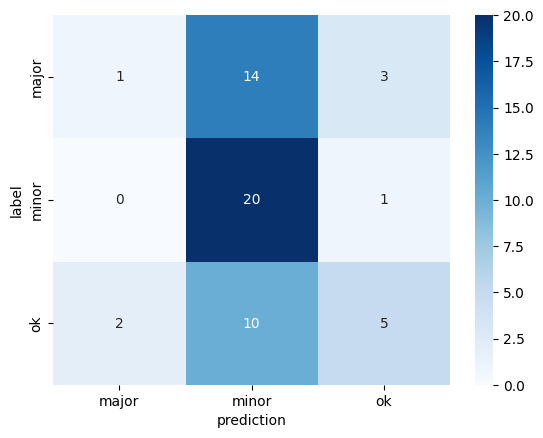

In [0]:
# METRIC EVALUATION
conf_matrix = pd.crosstab(prediction_results['label'], prediction_results['prediction'])

fig = plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt='d')

# Inference

In [0]:
# INFERENCE TEST DATA

# RUN INFERENCE
test_images = spark.table(tableName = "claim_insurance.2_silver.test_images") \
                   .withColumn(colName = "damage_prediction", col = predict_damage_udf(*columns))

test_images = test_images.selectExpr("image_name", "content", "damage_prediction.label as prediction", "damage_prediction.score as score")

test_images.toPandas().head(3)

,image_name,content,prediction,score
0,3_Medium.jpg,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...,major,0.501572
1,3_Low.jpg,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...,minor,0.506841
2,2_Low.jpg,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...,minor,0.506421
